In [3]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 599.9 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/8.0 MB 599.9 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/8.0 MB 599.9 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.0 MB 532.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.0 MB 532.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.0 MB 532.8 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.0 MB 

--- FINDING THE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) ---


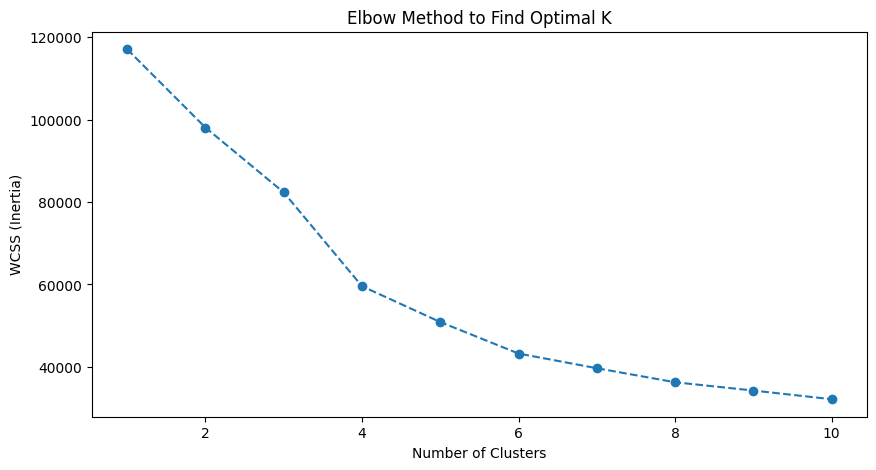


--- APPLYING K-MEANS CLUSTERING ---

Cluster Characteristics (Averages):
         lead_time         adr  total_of_special_requests  is_repeated_guest  \
cluster                                                                        
0         74.72155  141.801459                   1.416279           0.010543   
1         44.48549   83.993627                   0.246665           0.060562   
2        238.35651   88.725886                   0.266530           0.002215   

         stays_in_week_nights  
cluster                        
0                    2.785891  
1                    1.848684  
2                    3.372188  


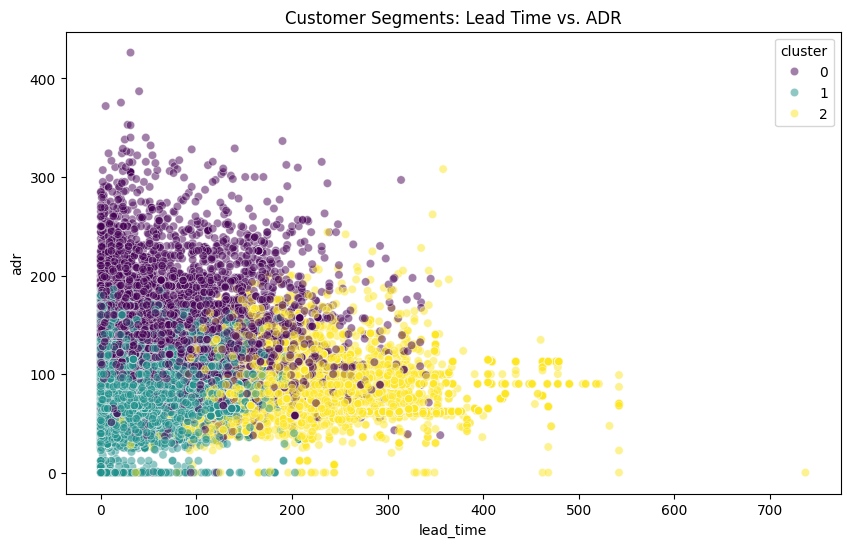

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data_warehouse_cleaned.csv')

features = ['lead_time', 'adr', 'total_of_special_requests', 'is_repeated_guest', 'stays_in_week_nights']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("--- FINDING THE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) ---")
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

print("\n--- APPLYING K-MEANS CLUSTERING ---")
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_analysis = df.groupby('cluster')[features].mean()
print("\nCluster Characteristics (Averages):")
print(cluster_analysis)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='lead_time', y='adr', hue='cluster', palette='viridis', alpha=0.5)
plt.title('Customer Segments: Lead Time vs. ADR')
plt.show()

In [5]:
final_kmeans = KMeans(n_clusters=3, init='k-means++', n_init="auto", random_state=42)

X_full = df[features]
X_full_scaled = scaler.fit_transform(X_full)

df['customer_segment'] = final_kmeans.fit_predict(X_full_scaled)

df.to_csv('data_warehouse_segmented.csv', index=False)
print("SUCCESS: Segmented data saved as 'data_warehouse_segmented.csv'")

SUCCESS: Segmented data saved as 'data_warehouse_segmented.csv'
